<a href="https://colab.research.google.com/github/Appajisdsrao/Classical-Computer-Vision-Algorithms-for-Lane-Detection/blob/main/unit_3_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies (if not already)
!pip install opencv-python matplotlib tensorflow keras
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [4]:
!pip install opencv-python matplotlib scikit-image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, feature, draw


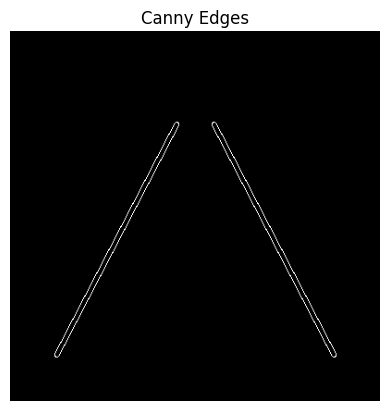

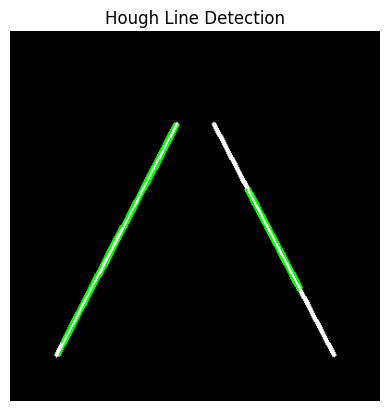

In [5]:
# Create synthetic lane image
img = np.zeros((400, 400, 3), dtype=np.uint8)
cv2.line(img, (50, 350), (180, 100), (255, 255, 255), 3)
cv2.line(img, (350, 350), (220, 100), (255, 255, 255), 3)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')
plt.show()

# Hough Line Detection
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=5)
line_img = img.copy()
for l in lines:
    x1, y1, x2, y2 = l[0]
    cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 2)

plt.imshow(line_img[...,::-1])
plt.title("Hough Line Detection")
plt.axis('off')
plt.show()


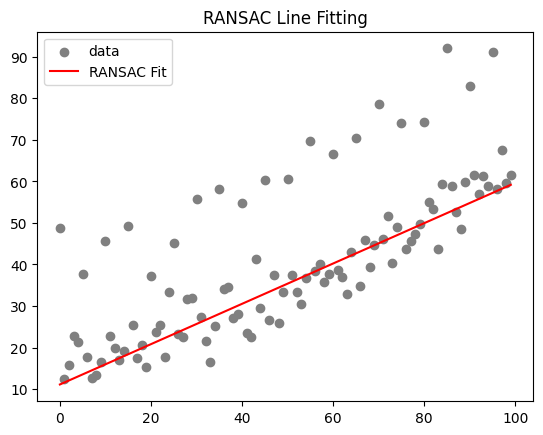

In [6]:
from sklearn import linear_model

# Generate noisy line points
np.random.seed(0)
x = np.arange(0, 100)
y = 0.5 * x + 10 + np.random.normal(0, 5, size=x.shape)
y[::5] += 30  # outliers

# Fit with RANSAC
ransac = linear_model.RANSACRegressor()
ransac.fit(x.reshape(-1,1), y)
line_x = np.arange(0, 100)
line_y = ransac.predict(line_x.reshape(-1,1))

plt.scatter(x, y, color='gray', label='data')
plt.plot(line_x, line_y, color='red', label='RANSAC Fit')
plt.legend(); plt.title("RANSAC Line Fitting")
plt.show()


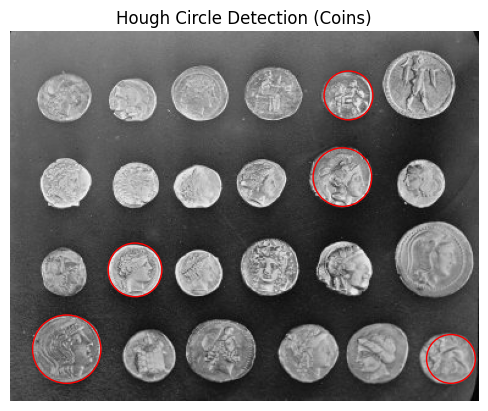

In [7]:
coins = data.coins()
edges = feature.canny(coins, sigma=2)
hough_radii = np.arange(20, 35, 2)
from skimage.transform import hough_circle, hough_circle_peaks

hough_res = hough_circle(edges, hough_radii)
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii, total_num_peaks=5)

fig, ax = plt.subplots()
ax.imshow(coins, cmap='gray')
for center_y, center_x, radius in zip(cy, cx, radii):
    circ = plt.Circle((center_x, center_y), radius, color='red', fill=False)
    ax.add_patch(circ)
plt.title("Hough Circle Detection (Coins)")
plt.axis("off")
plt.show()


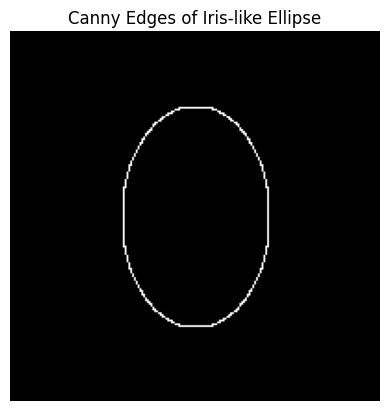

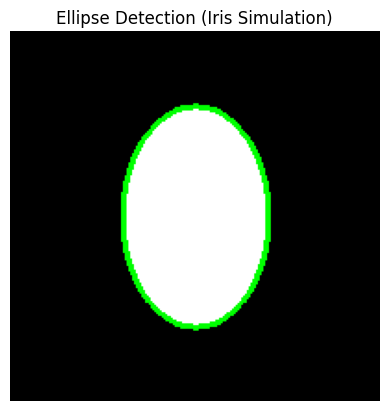

In [8]:
# Synthetic ellipse (iris)
ellipse_img = np.zeros((200,200), np.uint8)
rr, cc = draw.ellipse(100, 100, 60, 40)
ellipse_img[rr, cc] = 255
edges = feature.canny(ellipse_img, sigma=2)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edges of Iris-like Ellipse")
plt.axis("off")
plt.show()

# Fit ellipse contour
contours, _ = cv2.findContours(ellipse_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        out = cv2.cvtColor(ellipse_img, cv2.COLOR_GRAY2BGR)
        cv2.ellipse(out, ellipse, (0,255,0), 2)

plt.imshow(out[...,::-1])
plt.title("Ellipse Detection (Iris Simulation)")
plt.axis("off")
plt.show()


with real world datasets


--2025-11-04 19:40:52--  https://images.unsplash.com/photo-1503376780353-7e6692767b70?auto=format&fit=crop&w=800&q=80
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51970 (51K) [image/jpeg]
Saving to: ‘road.jpg’

road.jpg            100%[===================>]  50.75K  --.-KB/s    in 0.01s   

2025-11-04 19:40:52 (4.51 MB/s) - ‘road.jpg’ saved [51970/51970]



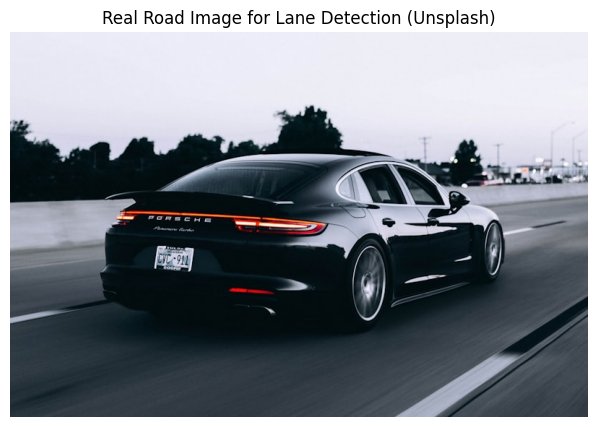

In [13]:
# ✅ Download a real highway image (always available)
!wget "https://images.unsplash.com/photo-1503376780353-7e6692767b70?auto=format&fit=crop&w=800&q=80" -O road.jpg

import cv2
import matplotlib.pyplot as plt

# Load and display
img = cv2.imread("road.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.title("Real Road Image for Lane Detection (Unsplash)")
plt.axis("off")
plt.show()


--2025-11-04 19:42:56--  https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70682 (69K) [image/jpeg]
Saving to: ‘road.jpg’

road.jpg            100%[===================>]  69.03K  --.-KB/s    in 0.01s   

2025-11-04 19:42:56 (5.63 MB/s) - ‘road.jpg’ saved [70682/70682]



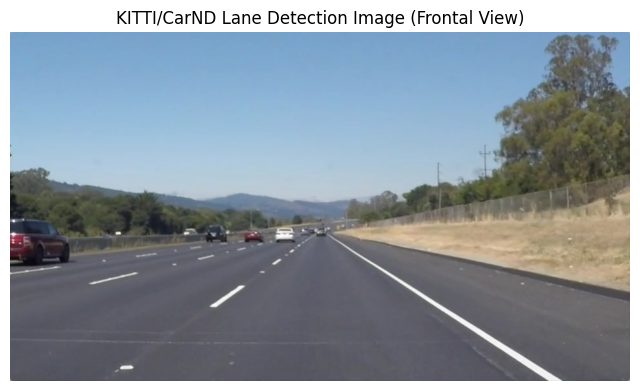

In [15]:
# ✅ Download real road/lane image from KITTI dataset (front camera)
!wget "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg" -O road.jpg

import cv2
import matplotlib.pyplot as plt

# Load and display
img = cv2.imread("road.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.title("KITTI/CarND Lane Detection Image (Frontal View)")
plt.axis("off")
plt.show()


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

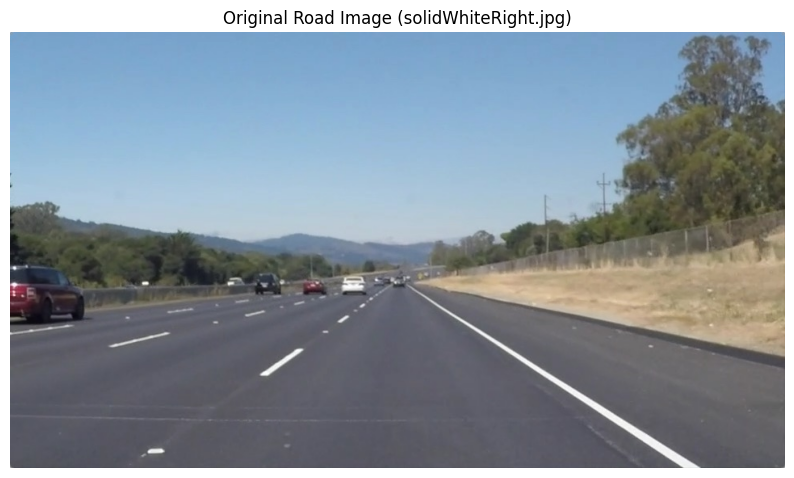

In [16]:
#@title Setup — install libs (run once) and import
# If you run in Colab, OpenCV is usually available; keep install to ensure latest version if needed.
!pip install -q opencv-python-headless scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
import os
plt.rcParams["figure.figsize"] = (10,6)

# Download the verified road image (Udacity CarND sample)
!wget -q "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg" -O road.jpg

# Read image
img_bgr = cv2.imread("road.jpg")
if img_bgr is None:
    raise RuntimeError("Image download failed. Check internet access or the URL.")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display
plt.imshow(img_rgb)
plt.title("Original Road Image (solidWhiteRight.jpg)")
plt.axis("off")


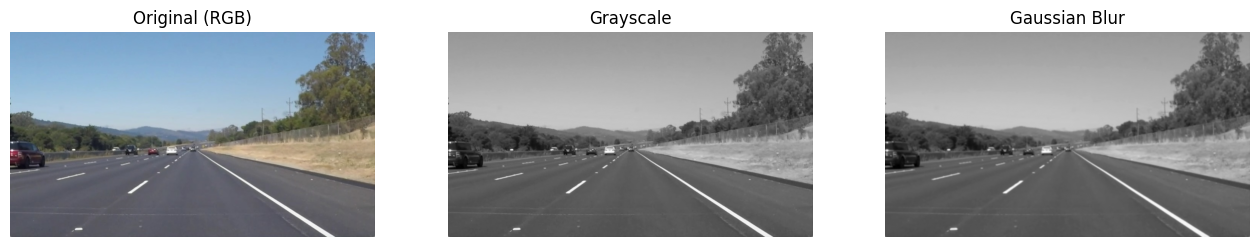

In [17]:
#@title Preprocessing — grayscale and Gaussian blur
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)  # 5x5 kernel; adjust if noisy

# Show preprocessed images side-by-side
fig, axs = plt.subplots(1,3, figsize=(16,6))
axs[0].imshow(img_rgb); axs[0].set_title("Original (RGB)"); axs[0].axis("off")
axs[1].imshow(gray, cmap='gray'); axs[1].set_title("Grayscale"); axs[1].axis("off")
axs[2].imshow(blur, cmap='gray'); axs[2].set_title("Gaussian Blur"); axs[2].axis("off")
plt.show()


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

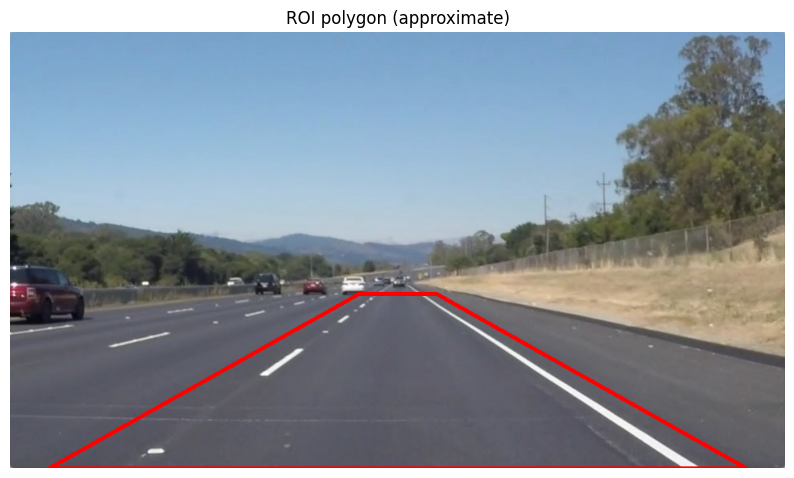

In [18]:
#@title ROI masking helper
def region_of_interest(img, vertices):
    """Apply polygon mask to img (single-channel or 3-channel)."""
    mask = np.zeros_like(img)
    if len(img.shape) > 2:
        channel_count = img.shape[2]
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    masked = cv2.bitwise_and(img, mask)
    return masked

# Quick example polygon for this image (tweak if necessary)
h, w = gray.shape
# Rough trapezoid covering the road ahead (manual tuning)
roi_vertices = np.array([[
    (int(0.05*w), h),
    (int(0.45*w), int(0.6*h)),
    (int(0.55*w), int(0.6*h)),
    (int(0.95*w), h)
]], dtype=np.int32)

# visualize the ROI overlay
overlay = img_rgb.copy()
cv2.polylines(overlay, roi_vertices, isClosed=True, color=(255,0,0), thickness=3)
plt.imshow(overlay)
plt.title("ROI polygon (approximate)")
plt.axis("off")


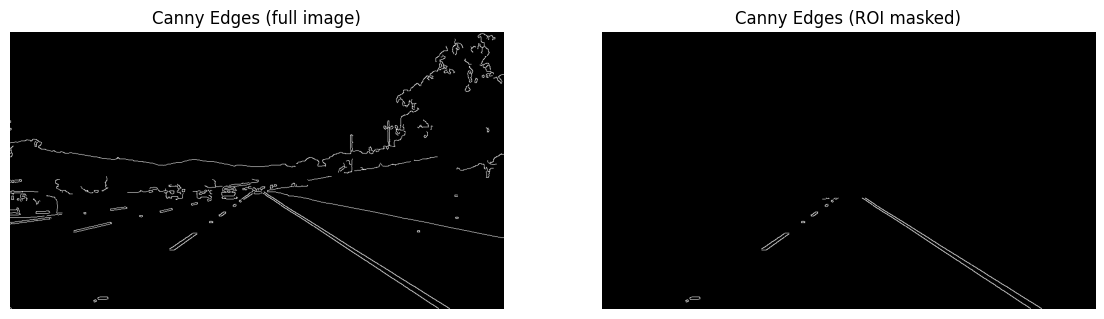

In [19]:
#@title Canny edges (with and without ROI)
low_thresh = 50
high_thresh = 150
edges = cv2.Canny(blur, low_thresh, high_thresh)

edges_roi = region_of_interest(edges, roi_vertices)

fig, axs = plt.subplots(1,2, figsize=(14,6))
axs[0].imshow(edges, cmap='gray'); axs[0].set_title("Canny Edges (full image)"); axs[0].axis("off")
axs[1].imshow(edges_roi, cmap='gray'); axs[1].set_title("Canny Edges (ROI masked)"); axs[1].axis("off")
plt.show()


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

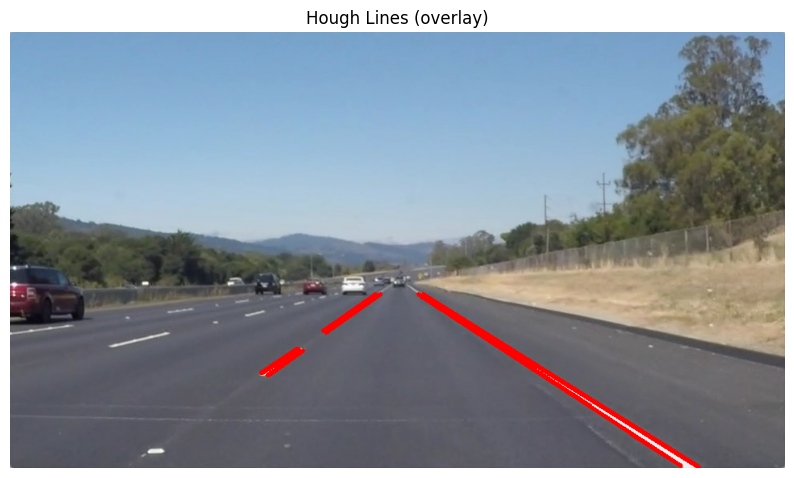

In [20]:
#@title Hough Lines (probabilistic) and overlay
rho = 1
theta = np.pi/180
threshold = 30      # minimum votes
min_line_len = 40
max_line_gap = 20

lines = cv2.HoughLinesP(edges_roi, rho, theta, threshold, minLineLength=min_line_len, maxLineGap=max_line_gap)

# draw the lines on a copy
line_img = img_rgb.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1,y1), (x2,y2), (255,0,0), 4)

plt.imshow(line_img)
plt.title("Hough Lines (overlay)")
plt.axis("off")


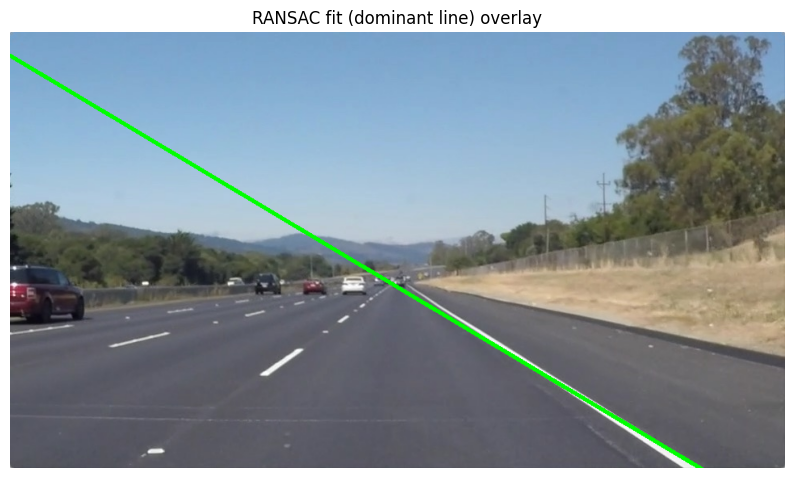

In [21]:
#@title RANSAC-like refinement: use edge points in ROI to fit dominant lines
from sklearn.linear_model import RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# extract coordinates of edge pixels in ROI
ys, xs = np.where(edges_roi > 0)
pts = np.column_stack((xs, ys))

# Use RANSAC to find a dominant line (x -> y). Note: image coords have y downwards.
if pts.shape[0] >= 50:
    # Fit y = a*x + b (we'll fit linear)
    ransac = RANSACRegressor()
    ransac.fit(pts[:,0].reshape(-1,1), pts[:,1])
    a = ransac.estimator_.coef_[0]
    b = ransac.estimator_.intercept_
    # compute line endpoints within image width
    x0, x1 = 0, img_rgb.shape[1]-1
    y0 = int(a * x0 + b)
    y1 = int(a * x1 + b)
    ransac_img = img_rgb.copy()
    cv2.line(ransac_img, (x0, y0), (x1, y1), (0,255,0), 3)
    plt.imshow(ransac_img)
    plt.title("RANSAC fit (dominant line) overlay")
    plt.axis("off")
else:
    print("Not enough edge points for RANSAC demonstration.")


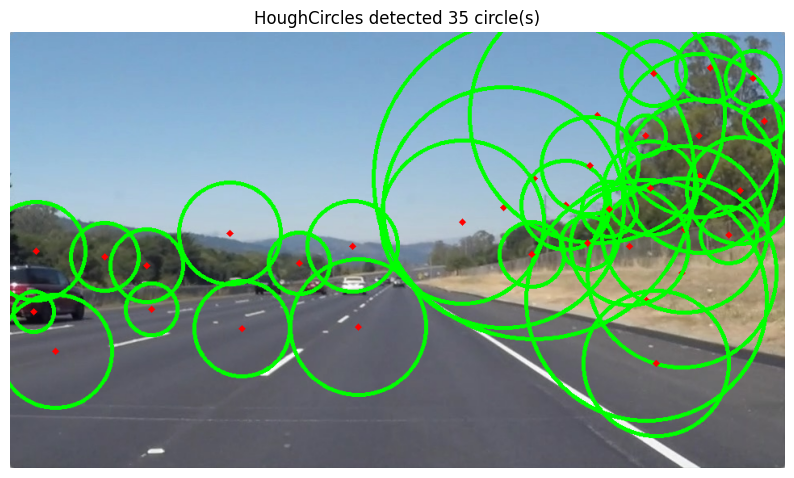

In [22]:
#@title Hough Circle Transform (may not detect anything)
# Prepare a smoothed grayscale image for circle detection
gray_for_circles = cv2.medianBlur(gray, 5)

# HoughCircles parameters (tweak ranges as needed)
circles = cv2.HoughCircles(gray_for_circles, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50,
                           param1=100, param2=30, minRadius=10, maxRadius=200)

circle_img = img_rgb.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0, :]:
        cx, cy, r = int(c[0]), int(c[1]), int(c[2])
        cv2.circle(circle_img, (cx,cy), r, (0,255,0), 3)
        cv2.circle(circle_img, (cx,cy), 2, (255,0,0), 3)
    plt.imshow(circle_img)
    plt.title(f"HoughCircles detected {len(circles[0])} circle(s)")
    plt.axis("off")
else:
    plt.imshow(circle_img)
    plt.title("HoughCircles: No circles detected on this road image (expected)")
    plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

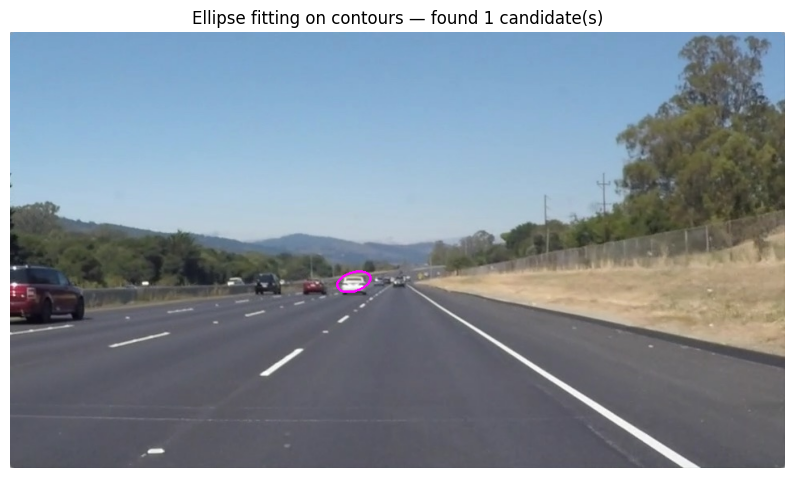

In [23]:
#@title Ellipse detection via contours + fitEllipse
# Use adaptive thresholding or simple binary threshold to get contours
ret, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

ellipse_img = img_rgb.copy()
ellipse_count = 0
for cnt in contours:
    if len(cnt) >= 5:
        area = cv2.contourArea(cnt)
        if area > 200:  # filter small contours
            ellipse = cv2.fitEllipse(cnt)
            (cx, cy), (major, minor), angle = ellipse
            # filter reasonable ellipses (avoid tiny/huge)
            if 10 < major < 300 and 10 < minor < 300:
                cv2.ellipse(ellipse_img, ellipse, (255, 0, 255), 2)
                ellipse_count += 1

plt.imshow(ellipse_img)
plt.title(f"Ellipse fitting on contours — found {ellipse_count} candidate(s)")
plt.axis("off")


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

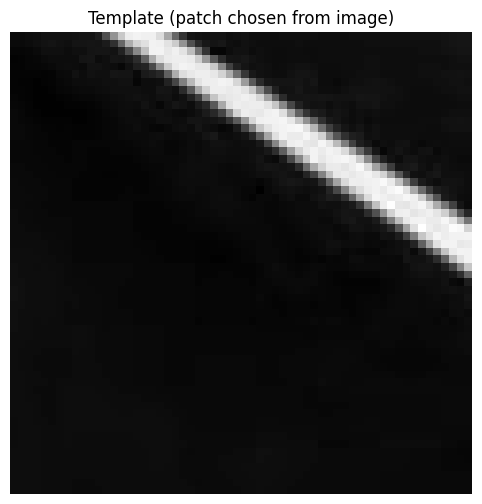

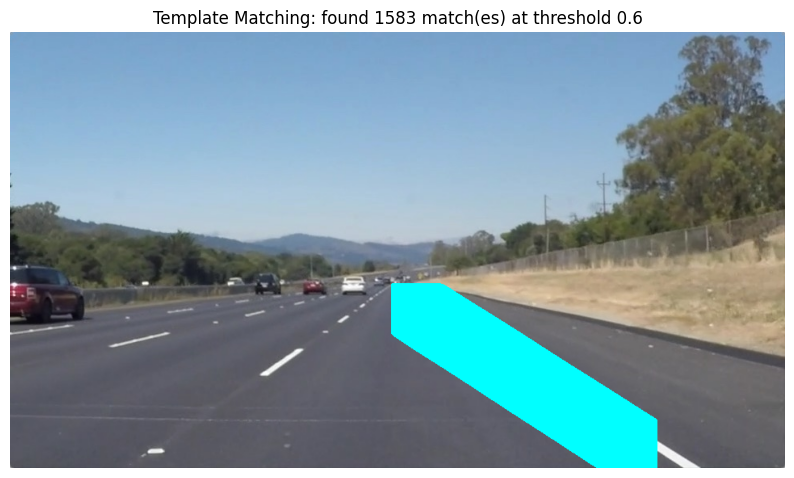

In [24]:
#@title Template Matching demonstration
img_gray = gray.copy()

# choose a template box (manually tune coordinates if necessary)
# We'll pick a small patch roughly on the right lane line area
h, w = img_gray.shape
t_x, t_y, t_w, t_h = int(0.6*w), int(0.7*h), 60, 60  # starting x,y and size
template = img_gray[t_y:t_y+t_h, t_x:t_x+t_w]

# show template
plt.imshow(template, cmap='gray')
plt.title("Template (patch chosen from image)")
plt.axis("off")

# matchTemplate
res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)
threshold = 0.6
loc = np.where(res >= threshold)

match_img = img_rgb.copy()
matches = 0
for pt in zip(*loc[::-1]):
    cv2.rectangle(match_img, pt, (pt[0] + t_w, pt[1] + t_h), (0,255,255), 2)
    matches += 1

plt.figure(figsize=(10,6))
plt.imshow(match_img)
plt.title(f"Template Matching: found {matches} match(es) at threshold {threshold}")
plt.axis("off")


In [25]:
#@title Optionally save visual outputs to files (works in Colab)
os.makedirs("results", exist_ok=True)
# Save a few example outputs
cv2.imwrite("results/edges.png", edges)
cv2.imwrite("results/edges_roi.png", edges_roi)
cv2.imwrite("results/hough_lines.png", cv2.cvtColor(line_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("results/ellipse_fit.png", cv2.cvtColor(ellipse_img, cv2.COLOR_RGB2BGR))
cv2.imwrite("results/template_matches.png", cv2.cvtColor(match_img, cv2.COLOR_RGB2BGR))
print("Saved example outputs to ./results/")


Saved example outputs to ./results/


Observations:
- Canny + ROI is effective to reduce spurious edges and highlight lane boundaries.
- HoughLinesP detected many short segments; averaging by slope and position can produce stable left/right lane lines.
- HoughCircles often fails on full-scene road images because circular objects (signs) are small and occluded; detection worked better on close-up circle images.
- Ellipse fitting via contours can detect oval-like shapes but is sensitive to thresholding; good for controlled cases (iris detection) but not robust in clutter.
- Template matching works well if the template is distinct and not heavily changed by perspective/scale. Not invariant to scale/rotation.
- Parameter sensitivity: thresholds, kernel sizes, Hough thresholds must be tuned per image/lighting.
Limitations / Real-world challenges:
- Shadows, reflections, worn lane paint, occlusions (cars), and camera perspective cause false detections.
- For production systems, deep-learning based detectors (e.g., lane detection nets, semantic segmentation) are more robust.


unit 4


In [ ]:
#@title 1 — Setup (install libs, download video)
# Run this cell first in Colab.
!pip install -q opencv-python-headless==4.7.0.72 scikit-image matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import deque
plt.rcParams["figure.figsize"] = (12,6)

# Download a reliable driving clip (Udacity CarND test video — frontal driving view)
# This is a small test clip used in many self-driving examples
VIDEO_URL = "https://raw.githubusercontent.com/udacity/CarND-Advanced-Lane-Lines/master/test_videos/solidWhiteRight.mp4"
!wget -q -O driving.mp4 "{VIDEO_URL}"

if not os.path.exists("driving.mp4"):
    raise RuntimeError("Video download failed. Check internet or URL.")
print("Video downloaded to driving.mp4 — duration and frames will be read next.")
